# Practical Work 03 - 2D Convex Hull

| Information | Details     |
| ----------- | ----------- |
| Course      | Computational Geometry (`INF2604`) |
| Professor   | Waldemar Celes (<celes@inf.puc-rio.br>) |
| Student     | Gabriel Ribeiro Gomes (<ggomes@inf.puc-rio.br>, <ribeiroggabriel@gmail.com>) |

## Setup and problem definition

We need to generate a report that fulfills the following requirements:

- Simulates a set of random points in a 2D plane.
- Implements an algorithm to compute the convex hull of the set of points.
- Visualizes the set of points and the computed convex hull using a plotting library.

In [1]:
import math
import random
import time

from concurrent.futures import ProcessPoolExecutor, as_completed

import matplotlib.pyplot as plt

from pydantic import BaseModel, Field, ValidationError, field_validator


class Point2D(BaseModel):
    """Strict 2D point with finite numeric coordinates."""

    x: float = Field(..., description="X coordinate")
    y: float = Field(..., description="Y coordinate")

    @field_validator("x", "y")
    @classmethod
    def _finite(cls, v: float) -> float:
        if not (isinstance(v, int | float) and math.isfinite(v)):
            raise ValueError("Coordinates must be finite numbers.")
        return float(v)

    def as_tuple(self) -> tuple[float, float]:
        return (self.x, self.y)


class Line2D(BaseModel):
    """Strict 2D line defined by two distinct points."""

    p1: Point2D
    p2: Point2D

    @field_validator("p2")
    @classmethod
    def _non_degenerate(cls, p2: Point2D, info):
        p1: Point2D = info.data["p1"]
        if p2.x == p1.x and p2.y == p1.y:
            raise ValueError("Line endpoints must be distinct (non-degenerate).")
        return p2


class PointsCloud(BaseModel):
    """Strict non-empty point cloud."""

    points: list[Point2D]

    @field_validator("points")
    @classmethod
    def _non_empty(cls, pts: list[Point2D]) -> list[Point2D]:
        if len(pts) == 0:
            raise ValueError("Point cloud must not be empty.")
        return pts


type Point = tuple[float, float]
type Line = tuple[Point, Point]


def _coerce_point(obj: Point2D | list[float]) -> Point2D:
    """Coerce a tuple-like or Point2D into a validated Point2D."""
    if isinstance(obj, Point2D):
        return obj
    try:
        x, y = obj
    except Exception as exc:
        raise ValidationError([exc], Point2D) from exc
    return Point2D(x=float(x), y=float(y))


def _coerce_line(obj: Line2D | list[list[float]]) -> Line2D:
    """Coerce a pair of points or Line2D into a validated Line2D."""
    if isinstance(obj, Line2D):
        return obj
    try:
        p1_raw, p2_raw = obj
        p1 = _coerce_point(p1_raw)
        p2 = _coerce_point(p2_raw)
        return Line2D(p1=p1, p2=p2)
    except Exception as exc:
        raise ValidationError([exc], Line2D) from exc


def _coerce_cloud(points: list[Point | Point2D]) -> PointsCloud:
    """Coerce a sequence of points into a validated PointsCloud."""
    pts = [_coerce_point(p) for p in points]
    return PointsCloud(points=list(pts))

In [2]:
def _vector_from(origin: Point2D, target: Point2D) -> tuple[float, float]:
    """Return vector (target - origin)."""
    return (target.x - origin.x, target.y - origin.y)


def _dot_product(v1: tuple[float, float], v2: tuple[float, float]) -> float:
    """Dot product in 2D."""
    return v1[0] * v2[0] + v1[1] * v2[1]


def _euclidean_norm(v: tuple[float, float]) -> float:
    """Euclidean norm in 2D."""
    return math.hypot(v[0], v[1])


def _cross_z(a: Point2D, b: Point2D, c: Point2D) -> float:
    """Scalar z-component of (b - a) x (c - a). >0 if c is left of ab; <0 if right."""
    abx, aby = b.x - a.x, b.y - a.y
    acx, acy = c.x - a.x, c.y - a.y
    return abx * acy - aby * acx


def dot_product(vector1: list[float], vector2: list[float]) -> float:
    """Compute the dot product of two 2D vectors.

    Args:
        vector1: First vector (x, y).
        vector2: Second vector (x, y).

    Returns:
        Scalar dot product.

    Raises:
        ValueError: If vectors are not 2D.
    """
    if len(vector1) != 2 or len(vector2) != 2:
        raise ValueError("Both vectors must be 2D (length 2).")
    return float(vector1[0]) * float(vector2[0]) + float(vector1[1]) * float(vector2[1])


def calculate_angle_between_lines(lineA: Line | Line2D, lineB: Line | Line2D) -> float:
    """Angle in degrees between two lines (each defined by two points).

    The result is in [0, 360). Degenerate lines are treated as zero angle.

    Args:
        lineA: First line as ((x1, y1), (x2, y2)) or Line2D.
        lineB: Second line as ((x3, y3), (x4, y4)) or Line2D.

    Returns:
        Angle (degrees) in [0, 360).
    """
    L1 = _coerce_line(lineA)
    L2 = _coerce_line(lineB)

    u = _vector_from(L1.p2, L1.p1)
    v = _vector_from(L2.p2, L2.p1)

    norm_u = _euclidean_norm(u)
    norm_v = _euclidean_norm(v)
    if norm_u == 0 or norm_v == 0:
        return 0.0

    cosine = _dot_product(u, v) / (norm_u * norm_v)
    cosine = max(-1.0, min(1.0, cosine))  # clamp
    angle = math.degrees(math.acos(cosine)) % 360
    return 360 - angle if angle - 180 >= 0 else angle


def plot_points_cloud(
    points: list[Point | Point2D],
    xlim: tuple[float, float] = (200, 550),
    ylim: tuple[float, float] = (100, 420),
    title: str = "Point Cloud",
) -> None:
    """Scatter plot for a 2D point cloud, with clean styling."""
    cloud = _coerce_cloud(points)
    xs = [p.x for p in cloud.points]
    ys = [p.y for p in cloud.points]

    plt.figure(figsize=(7.6, 5.2), dpi=150)
    ax = plt.gca()
    ax.scatter(xs, ys, s=30, alpha=0.95, edgecolor="black", linewidth=0.6)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(title)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
    ax.set_aspect("equal")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    plt.tight_layout()
    plt.show()


def _plot_convex_hull(
    points: PointsCloud,
    hull_indices: list[int],
    xlim: tuple[float, float] = (200, 570),
    ylim: tuple[float, float] = (100, 420),
    title: str = "Convex Hull (Gift Wrapping)",
) -> None:
    """Draw cloud + hull with labels and a clean style."""
    xs = [p.x for p in points.points]
    ys = [p.y for p in points.points]

    plt.figure(figsize=(7.6, 5.2), dpi=150)
    ax = plt.gca()

    ax.scatter(
        x=xs,
        y=ys,
        s=28,
        alpha=0.95,
        edgecolor="black",
        linewidth=0.5,
        label="Points",
    )

    if hull_indices:
        cycle = [*list(hull_indices), hull_indices[0]]
        hx = [points.points[i].x for i in cycle]
        hy = [points.points[i].y for i in cycle]
        ax.plot(hx, hy, linewidth=2.0, label="Convex Hull")
        ax.scatter(
            [points.points[i].x for i in hull_indices],
            [points.points[i].y for i in hull_indices],
            s=38,
            marker="o",
            linewidth=0.8,
            edgecolor="black",
            label="Hull vertices",
        )
        ax.annotate(
            "start",
            (points.points[hull_indices[0]].x, points.points[hull_indices[0]].y),
            xytext=(6, 6),
            textcoords="offset points",
        )

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
    ax.set_aspect("equal")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()


def gift_wrapping(
    points: list[Point | Point2D],
    measure_time: bool = False,
    plot: bool = False,
) -> float | list[int]:
    """Jarvis March convex hull (2D), returning hull vertex indices.

    Args:
        points: list of points ((x, y) or Point2D).
        measure_time: If True, return only the execution time (seconds).
        plot: If True, renders point cloud and hull.

    Returns:
        If measure_time=True: float execution time in seconds.
        Else: list of hull vertex indices (counter-clockwise order based on pivot rule).
    """
    start_timestamp = time.time()
    cloud = _coerce_cloud(points)
    num_points = len(cloud.points)

    if num_points == 0:
        return 0.0 if measure_time else []

    pivot_index = 0
    for idx in range(1, num_points):
        is_more_right = cloud.points[idx].x > cloud.points[pivot_index].x
        is_same_x = cloud.points[idx].x == cloud.points[pivot_index].x
        is_lower_y = cloud.points[idx].y < cloud.points[pivot_index].y
        if is_more_right or (is_same_x and is_lower_y):
            pivot_index = idx

    hull_indices: list[int] = []
    current_index = pivot_index

    while True:
        hull_indices.append(current_index)
        candidate_index = (current_index + 1) % num_points
        for test_index in range(num_points):
            if test_index == current_index:
                continue

            orientation = _cross_z(
                cloud.points[current_index],
                cloud.points[candidate_index],
                cloud.points[test_index],
            )

            if orientation < 0:
                candidate_index = test_index
            elif orientation == 0:
                vec_candidate = _vector_from(
                    cloud.points[current_index], cloud.points[candidate_index]
                )
                vec_test = _vector_from(
                    cloud.points[current_index], cloud.points[test_index]
                )
                if _euclidean_norm(vec_test) > _euclidean_norm(vec_candidate):
                    candidate_index = test_index

        current_index = candidate_index
        if current_index == pivot_index:
            break

    elapsed = time.time() - start_timestamp

    if measure_time:
        return float(elapsed)

    if plot:
        _plot_convex_hull(cloud, hull_indices)
    return hull_indices

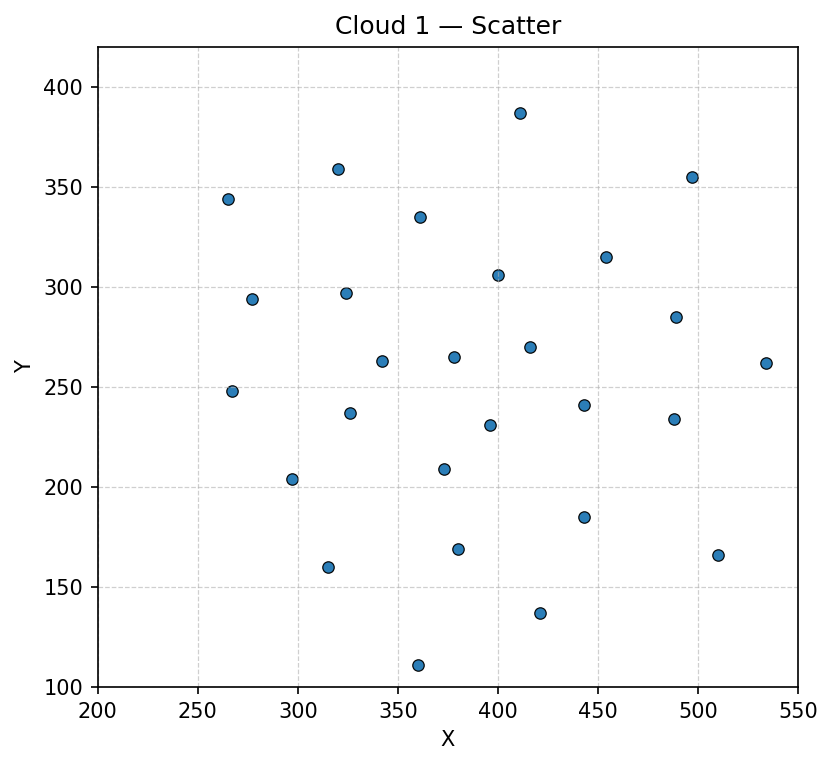

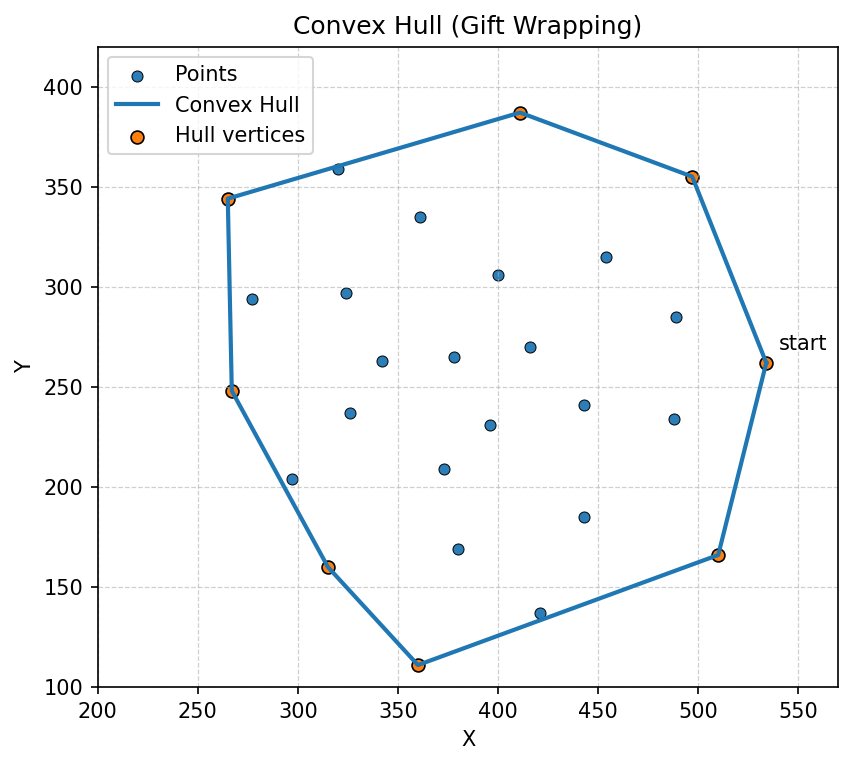

[26, 24, 21, 18, 17, 15, 20, 25]

In [3]:
cloud1: list[Point] = [
    (326, 237),
    (373, 209),
    (378, 265),
    (443, 241),
    (396, 231),
    (416, 270),
    (361, 335),
    (324, 297),
    (400, 306),
    (454, 315),
    (489, 285),
    (488, 234),
    (443, 185),
    (421, 137),
    (380, 169),
    (315, 160),
    (297, 204),
    (267, 248),
    (265, 344),
    (342, 263),
    (360, 111),
    (411, 387),
    (320, 359),
    (277, 294),
    (497, 355),
    (510, 166),
    (534, 262),
]


plot_points_cloud(cloud1, title="Cloud 1 — Scatter")
gift_wrapping(cloud1, measure_time=False, plot=True)

In [4]:
for i, point in enumerate([26, 24, 21, 18, 17, 15, 20, 25]):
    print(f"Vertex {i} counter-clockwise: cloud1[{point}]={cloud1[point]}")

Vertex 0 counter-clockwise: cloud1[26]=(534, 262)
Vertex 1 counter-clockwise: cloud1[24]=(497, 355)
Vertex 2 counter-clockwise: cloud1[21]=(411, 387)
Vertex 3 counter-clockwise: cloud1[18]=(265, 344)
Vertex 4 counter-clockwise: cloud1[17]=(267, 248)
Vertex 5 counter-clockwise: cloud1[15]=(315, 160)
Vertex 6 counter-clockwise: cloud1[20]=(360, 111)
Vertex 7 counter-clockwise: cloud1[25]=(510, 166)


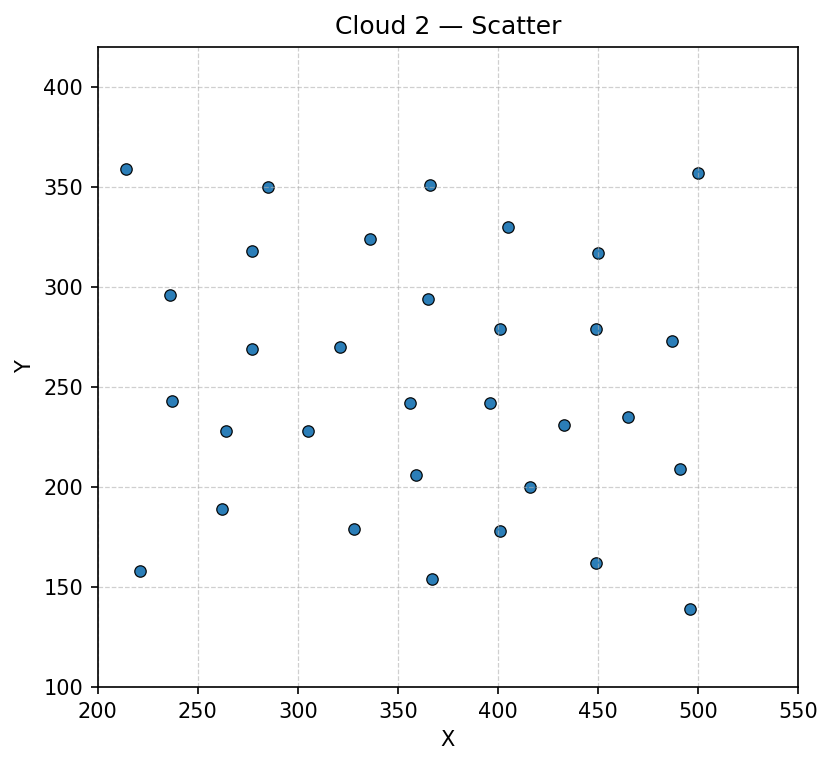

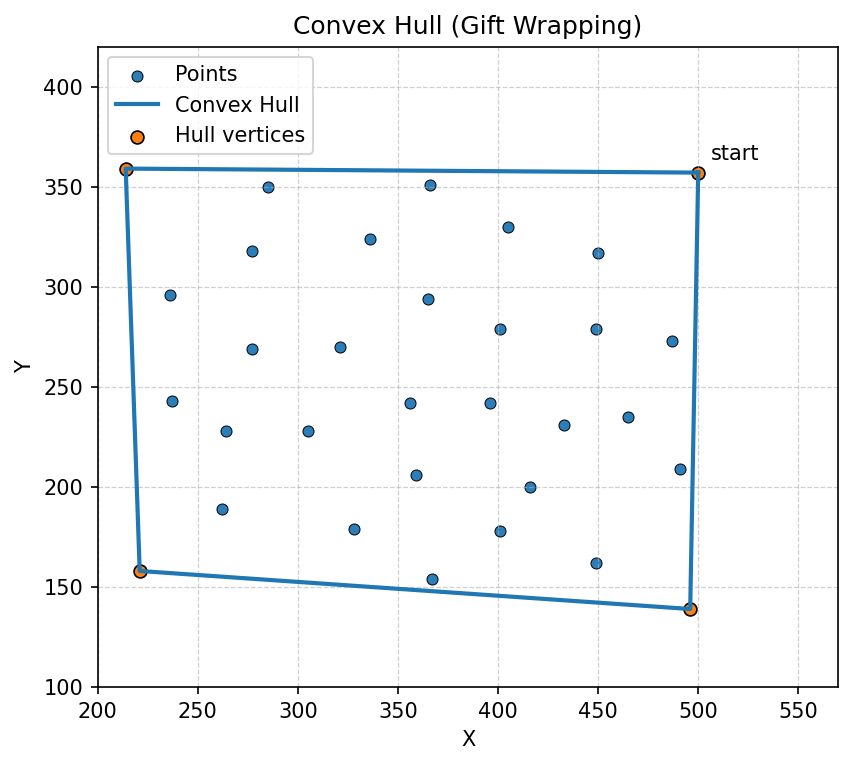

[31, 4, 0, 18]

In [5]:
cloud2: list[Point] = [
    (221, 158),
    (328, 179),
    (264, 228),
    (262, 189),
    (214, 359),
    (236, 296),
    (237, 243),
    (277, 269),
    (305, 228),
    (321, 270),
    (277, 318),
    (336, 324),
    (401, 279),
    (356, 242),
    (359, 206),
    (401, 178),
    (367, 154),
    (449, 162),
    (496, 139),
    (491, 209),
    (416, 200),
    (433, 231),
    (465, 235),
    (449, 279),
    (405, 330),
    (365, 294),
    (396, 242),
    (285, 350),
    (366, 351),
    (450, 317),
    (487, 273),
    (500, 357),
]


plot_points_cloud(cloud2, title="Cloud 2 — Scatter")
gift_wrapping(cloud2, measure_time=False, plot=True)

In [6]:
for i, point in enumerate([31, 4, 0, 18]):
    print(f"Vertex {i} counter-clockwise: cloud2[{point}]={cloud2[point]}")

Vertex 0 counter-clockwise: cloud2[31]=(500, 357)
Vertex 1 counter-clockwise: cloud2[4]=(214, 359)
Vertex 2 counter-clockwise: cloud2[0]=(221, 158)
Vertex 3 counter-clockwise: cloud2[18]=(496, 139)


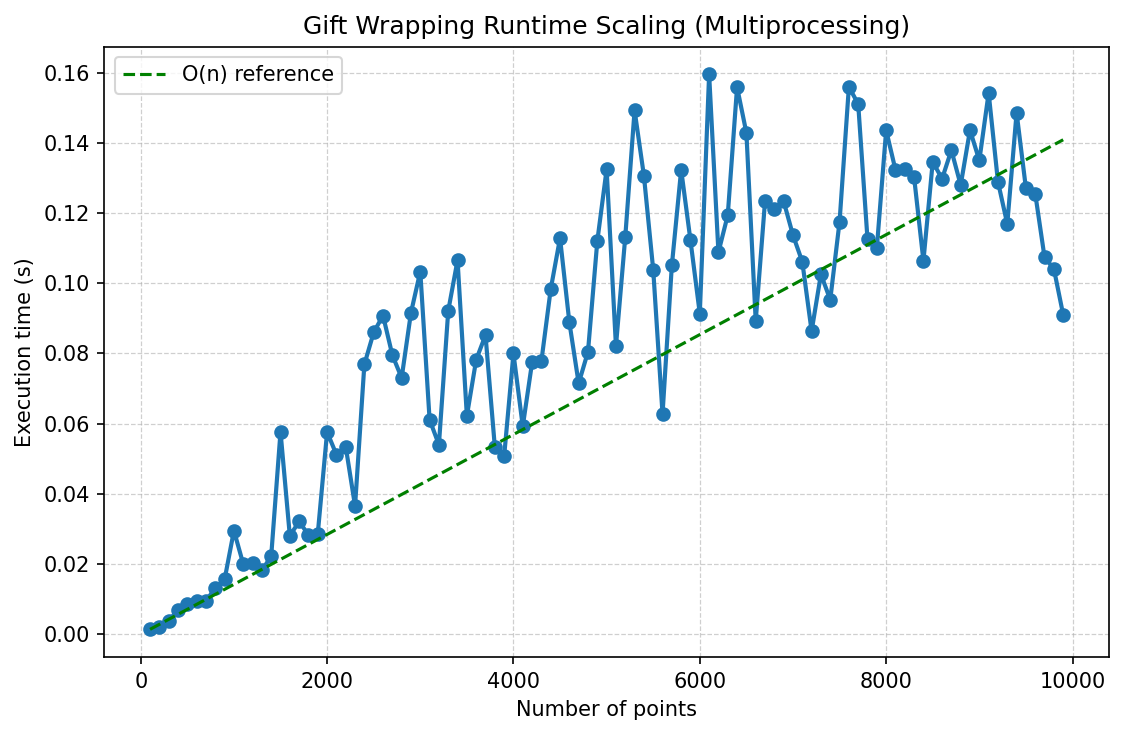

In [ ]:
def _random_cloud(
    n_points: int,
    seed: int = 841,
    x_range: tuple[int, int] = (100, 500),
    y_range: tuple[int, int] = (100, 500),
) -> list[Point]:
    """Generate a random point cloud with a fixed seed for reproducibility."""
    rng = random.Random(seed)
    xs = [rng.randint(x_range[0], x_range[1]) for _ in range(n_points)]
    ys = [rng.randint(y_range[0], y_range[1]) for _ in range(n_points)]
    return list(zip(xs, ys, strict=True))


def _time_gift_wrapping_worker(
    n_points: int, base_seed: int = 841
) -> tuple[int, float]:
    """Worker: build a cloud of size n and return (n, elapsed_seconds)."""
    seed = base_seed + n_points * 13
    cloud = _random_cloud(n_points, seed=seed)
    elapsed = gift_wrapping(cloud, measure_time=True, plot=False)
    return n_points, float(elapsed)


def evaluate_scaling_multiprocess(
    sizes_to_test: list[int] = (100 * i for i in range(1, 100)),
    max_workers: int | None = None,
) -> tuple[list[int], list[float]]:
    """Evaluate runtime scaling with a process pool.

    Args:
        sizes_to_test: Collection of point counts to test.
        max_workers: Number of processes (defaults to os.cpu_count()).

    Returns:
        (sorted_sizes, times) aligned by index.
    """
    time_by_size: dict[int, float] = {}
    with ProcessPoolExecutor(max_workers=max_workers) as pool:
        futures = [pool.submit(_time_gift_wrapping_worker, n) for n in sizes_to_test]
        for future in as_completed(futures):
            n, t = future.result()
            time_by_size[n] = t

    sizes_sorted = sorted(time_by_size.keys())
    times_sorted = [time_by_size[n] for n in sizes_sorted]
    return sizes_sorted, times_sorted


def plot_timing_curve(sizes: list[int], times: list[float]) -> None:
    """Plot execution time vs number of points."""
    plt.figure(figsize=(7.6, 5.0), dpi=150)
    ax = plt.gca()
    ax.plot(sizes, times, marker="o", linewidth=2)
    ax.set_xlabel("Number of points")
    ax.set_ylabel("Execution time (s)")
    ax.set_title("Gift Wrapping Runtime Scaling (Multiprocessing)")
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)

    if sizes and times:
        n0 = sizes[0]
        t0 = times[0]
        ref_xs = [n0, sizes[-1]]
        ref_ys = [t0, t0 * (sizes[-1] / n0)]
        ax.plot(ref_xs, ref_ys, linestyle="--", color="green", label="O(n) reference")
        ax.legend(frameon=True)

    plt.tight_layout()
    plt.show()


sizes, times = evaluate_scaling_multiprocess(
    sizes_to_test=[100 * i for i in range(1, 100)],
)
plot_timing_curve(sizes, times)